In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import cv2
import os
import glob
import PIL.Image as Image

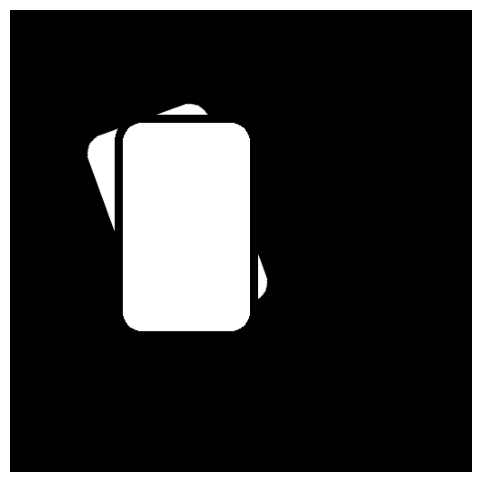

In [7]:
# Create a black background image
h, w = 512, 512
img = np.zeros((h, w, 3), dtype=np.uint8)

def draw_rounded_rect(image, top_left, size, radius, fill_color, edge_color, edge_thickness):
    x, y = top_left
    rect_w, rect_h = size
    x2, y2 = x + rect_w, y + rect_h

    # Fill: center cross + corner circles
    cv2.rectangle(image, (x + radius, y), (x2 - radius, y2), fill_color, thickness=-1)
    cv2.rectangle(image, (x, y + radius), (x2, y2 - radius), fill_color, thickness=-1)
    cv2.circle(image, (x + radius, y + radius), radius, fill_color, thickness=-1)
    cv2.circle(image, (x2 - radius, y + radius), radius, fill_color, thickness=-1)
    cv2.circle(image, (x + radius, y2 - radius), radius, fill_color, thickness=-1)
    cv2.circle(image, (x2 - radius, y2 - radius), radius, fill_color, thickness=-1)

    # Border: lines + corner arcs
    cv2.line(image, (x + radius, y), (x2 - radius, y), edge_color, edge_thickness)
    cv2.line(image, (x + radius, y2), (x2 - radius, y2), edge_color, edge_thickness)
    cv2.line(image, (x, y + radius), (x, y2 - radius), edge_color, edge_thickness)
    cv2.line(image, (x2, y + radius), (x2, y2 - radius), edge_color, edge_thickness)
    cv2.ellipse(image, (x + radius, y + radius), (radius, radius), 180, 0, 90, edge_color, edge_thickness)
    cv2.ellipse(image, (x2 - radius, y + radius), (radius, radius), 270, 0, 90, edge_color, edge_thickness)
    cv2.ellipse(image, (x2 - radius, y2 - radius), (radius, radius), 0, 0, 90, edge_color, edge_thickness)
    cv2.ellipse(image, (x + radius, y2 - radius), (radius, radius), 90, 0, 90, edge_color, edge_thickness)

def draw_rounded_rect_mask(mask, top_left, size, radius, value=255):
    x, y = top_left
    rect_w, rect_h = size
    x2, y2 = x + rect_w, y + rect_h
    cv2.rectangle(mask, (x + radius, y), (x2 - radius, y2), value, thickness=-1)
    cv2.rectangle(mask, (x, y + radius), (x2, y2 - radius), value, thickness=-1)
    cv2.circle(mask, (x + radius, y + radius), radius, value, thickness=-1)
    cv2.circle(mask, (x2 - radius, y + radius), radius, value, thickness=-1)
    cv2.circle(mask, (x + radius, y2 - radius), radius, value, thickness=-1)
    cv2.circle(mask, (x2 - radius, y2 - radius), radius, value, thickness=-1)

def draw_rotated_rounded_rect(image, center, size, radius, angle_deg, fill_color, edge_color, edge_thickness):
    rect_w, rect_h = size
    pad = radius + edge_thickness + 6
    patch_h = rect_h + 2 * pad
    patch_w = rect_w + 2 * pad

    patch = np.zeros((patch_h, patch_w, 3), dtype=np.uint8)
    mask = np.zeros((patch_h, patch_w), dtype=np.uint8)

    draw_rounded_rect(patch, (pad, pad), size, radius, fill_color, edge_color, edge_thickness)
    draw_rounded_rect_mask(mask, (pad, pad), size, radius, value=255)

    rot_center = (patch_w // 2, patch_h // 2)
    M = cv2.getRotationMatrix2D(rot_center, angle_deg, 1.0)
    patch_rot = cv2.warpAffine(patch, M, (patch_w, patch_h), flags=cv2.INTER_LINEAR, borderValue=(0, 0, 0))
    mask_rot = cv2.warpAffine(mask, M, (patch_w, patch_h), flags=cv2.INTER_NEAREST, borderValue=0)

    x0 = int(center[0] - patch_w // 2)
    y0 = int(center[1] - patch_h // 2)
    x1 = x0 + patch_w
    y1 = y0 + patch_h

    # Clip to image bounds
    ix0, iy0 = max(0, x0), max(0, y0)
    ix1, iy1 = min(image.shape[1], x1), min(image.shape[0], y1)

    if ix0 >= ix1 or iy0 >= iy1:
        return

    px0, py0 = ix0 - x0, iy0 - y0
    px1, py1 = px0 + (ix1 - ix0), py0 + (iy1 - iy0)

    roi = image[iy0:iy1, ix0:ix1]
    patch_roi = patch_rot[py0:py1, px0:px1]
    mask_roi = mask_rot[py0:py1, px0:px1] > 0
    roi[mask_roi] = patch_roi[mask_roi]

# Portrait rectangles: height > width
rect_size = (150, 240)
radius = 26
edge_thickness = 8

# Bottom rectangle rotated by 20 degrees (drawn first)
bottom_center = (110 + rect_size[0] // 2, 110 + rect_size[1] // 2)
draw_rotated_rounded_rect(
    img,
    center=bottom_center,
    size=rect_size,
    radius=radius,
    angle_deg=20,
    fill_color=(255, 255, 255),
    edge_color=(0, 0, 0),
    edge_thickness=edge_thickness,
)

# Top rectangle (drawn second, so it overlaps on top)
draw_rounded_rect(
    img,
    top_left=(120, 120),
    size=rect_size,
    radius=radius,
    fill_color=(255, 255, 255),
    edge_color=(0, 0, 0),
    edge_thickness=edge_thickness,
)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

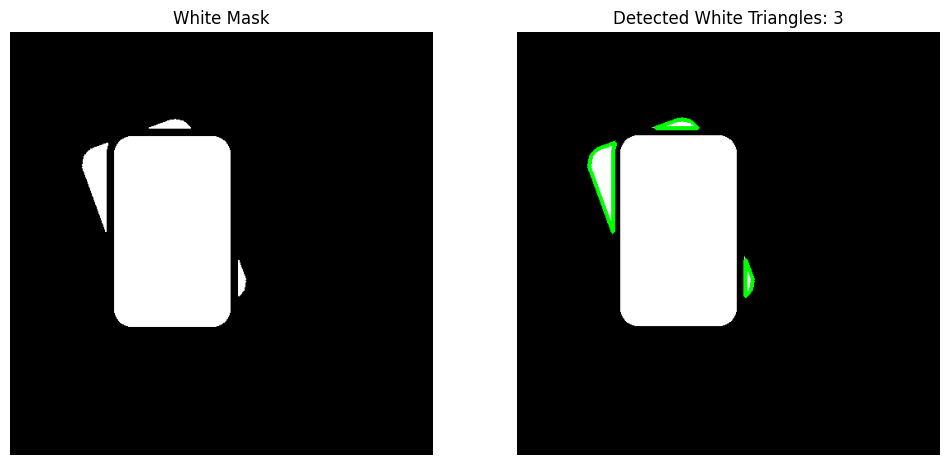

Detected white triangles: 3


In [9]:
# Detect white triangles and display their contours
img_bgr = img.copy()

# Build a mask for white pixels
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
_, white_mask = cv2.threshold(img_gray, 200, 255, cv2.THRESH_BINARY)

# Clean small noise while preserving tiny wedges
kernel = np.ones((2, 2), np.uint8)
white_mask = cv2.morphologyEx(white_mask, cv2.MORPH_OPEN, kernel)

# Find contours in the white mask
contours, _ = cv2.findContours(white_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

triangle_contours = []
for cnt in contours:
    area = cv2.contourArea(cnt)

    # Keep only small/medium white pieces (exclude the large main card)
    if area < 30 or area > 12000:
        continue

    perimeter = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.02 * perimeter, True)

    # Triangle-like check based on min enclosing triangle
    tri_area, _ = cv2.minEnclosingTriangle(cnt)
    if tri_area is None or tri_area <= 0:
        continue

    triangle_fill_ratio = area / tri_area

    # Accept exact triangles or close triangle-like contours
    is_triangle = len(approx) == 3
    is_triangle_like = 3 <= len(approx) <= 6 and triangle_fill_ratio > 0.62

    if is_triangle or is_triangle_like:
        triangle_contours.append(cnt)

# Draw triangle contours on a copy of the image
result = img_bgr.copy()
cv2.drawContours(result, triangle_contours, -1, (0, 255, 0), 3)

# Show mask and detected contours
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(white_mask, cmap="gray")
ax[0].set_title("White Mask")
ax[0].axis("off")

ax[1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
ax[1].set_title(f"Detected White Triangles: {len(triangle_contours)}")
ax[1].axis("off")

plt.show()

print(f"Detected white triangles: {len(triangle_contours)}")

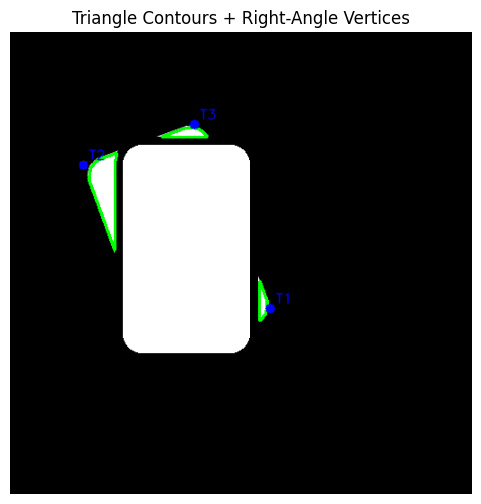

Triangle 1: right-angle vertex at (np.int64(288), np.int64(306)), angle ~ 122.91 deg
Triangle 2: right-angle vertex at (np.int64(81), np.int64(147)), angle ~ 91.76 deg
Triangle 3: right-angle vertex at (np.int64(204), np.int64(102)), angle ~ 119.70 deg


In [10]:
# Find each triangle's right-angle vertex and display it
img_bgr = img.copy()

# Reuse detected triangles if available; otherwise detect them
if "triangle_contours" not in globals() or len(triangle_contours) == 0:
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, white_mask = cv2.threshold(img_gray, 200, 255, cv2.THRESH_BINARY)
    kernel = np.ones((2, 2), np.uint8)
    white_mask = cv2.morphologyEx(white_mask, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(white_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    triangle_contours = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 30 or area > 12000:
            continue

        perimeter = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * perimeter, True)
        tri_area, _ = cv2.minEnclosingTriangle(cnt)
        if tri_area is None or tri_area <= 0:
            continue

        ratio = area / tri_area
        if len(approx) == 3 or (3 <= len(approx) <= 6 and ratio > 0.62):
            triangle_contours.append(cnt)

def angle_at_vertex(a, b, c):
    # Angle ABC in degrees
    ba = a - b
    bc = c - b
    denom = np.linalg.norm(ba) * np.linalg.norm(bc)
    if denom == 0:
        return 0.0
    cosang = np.clip(np.dot(ba, bc) / denom, -1.0, 1.0)
    return float(np.degrees(np.arccos(cosang)))

result = img_bgr.copy()
cv2.drawContours(result, triangle_contours, -1, (0, 255, 0), 2)

right_vertices = []
for i, cnt in enumerate(triangle_contours, start=1):
    perimeter = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.02 * perimeter, True)

    if len(approx) == 3:
        tri_pts = approx[:, 0, :].astype(np.float32)
    else:
        _, tri = cv2.minEnclosingTriangle(cnt)
        tri_pts = tri.reshape(3, 2).astype(np.float32)

    angles = [
        angle_at_vertex(tri_pts[2], tri_pts[0], tri_pts[1]),
        angle_at_vertex(tri_pts[0], tri_pts[1], tri_pts[2]),
        angle_at_vertex(tri_pts[1], tri_pts[2], tri_pts[0]),
    ]

    right_idx = int(np.argmin([abs(a - 90.0) for a in angles]))
    right_pt = tuple(np.round(tri_pts[right_idx]).astype(int))
    right_angle = angles[right_idx]

    right_vertices.append((i, right_pt, right_angle))

    cv2.circle(result, right_pt, 5, (255, 0, 0), -1)
    cv2.putText(
        result,
        f"T{i}",
        (right_pt[0] + 6, right_pt[1] - 6),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1,
        cv2.LINE_AA,
    )

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Triangle Contours + Right-Angle Vertices")
plt.axis("off")
plt.show()

for tri_id, pt, ang in right_vertices:
    print(f"Triangle {tri_id}: right-angle vertex at {pt}, angle ~ {ang:.2f} deg")

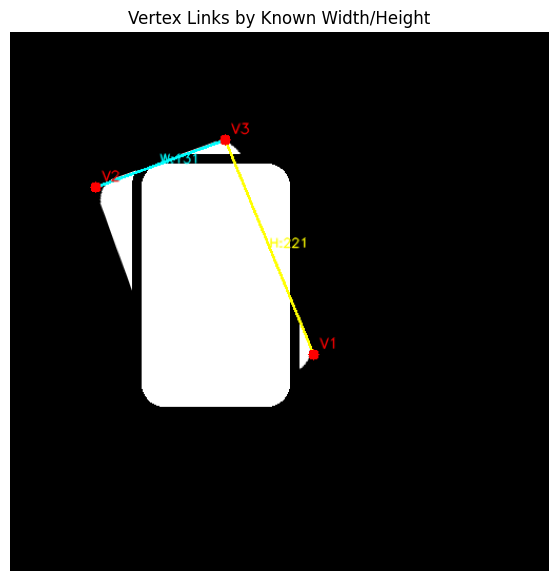

Rectangle groups (by connected vertices):
Group 1: ['V1', 'V2', 'V3']

Matched edges:
V1-V3: type=H, target=240, dist=220.62, err=19.38
V2-V3: type=W, target=150, dist=130.97, err=19.03


In [11]:
# Classify vertices as belonging to the same rectangle using known side lengths
# Rule: from each vertex, try one line of length ~width and one of length ~height

if "right_vertices" not in globals() or len(right_vertices) == 0:
    raise ValueError("Run Cell 4 first to compute right-angle vertices.")

img_vis = img.copy()
points = np.array([pt for _, pt, _ in right_vertices], dtype=np.float32)
num_pts = len(points)

# Known rectangle side lengths (width, height)
rect_w, rect_h = rect_size
length_specs = [("W", float(rect_w)), ("H", float(rect_h))]
length_tol = 20.0

# Build candidate edges: at most one W-edge and one H-edge per vertex
edge_map = {}
for i in range(num_pts):
    used_neighbors = set()
    for side_tag, target_len in length_specs:
        best_j = None
        best_err = 1e9
        best_dist = None

        for j in range(num_pts):
            if i == j or j in used_neighbors:
                continue
            dist = float(np.linalg.norm(points[j] - points[i]))
            err = abs(dist - target_len)
            if err <= length_tol and err < best_err:
                best_err = err
                best_j = j
                best_dist = dist

        if best_j is not None:
            used_neighbors.add(best_j)
            a, b = sorted((i, best_j))
            key = (a, b)
            record = (side_tag, target_len, best_dist, best_err)

            # Keep the best matching label for each undirected edge
            if key not in edge_map or best_err < edge_map[key][3]:
                edge_map[key] = record

edges = [(a, b, *edge_map[(a, b)]) for (a, b) in edge_map]

# Connected components = rectangle groups
adj = {i: set() for i in range(num_pts)}
for a, b, _, _, _, _ in edges:
    adj[a].add(b)
    adj[b].add(a)

visited = set()
components = []
for i in range(num_pts):
    if i in visited:
        continue
    stack = [i]
    comp = []
    while stack:
        u = stack.pop()
        if u in visited:
            continue
        visited.add(u)
        comp.append(u)
        for v in adj[u]:
            if v not in visited:
                stack.append(v)
    components.append(sorted(comp))

# Draw lines and vertices
for a, b, side_tag, _, dist, _ in edges:
    p1 = tuple(points[a].astype(int))
    p2 = tuple(points[b].astype(int))
    color = (255, 255, 0) if side_tag == "W" else (0, 255, 255)
    cv2.line(img_vis, p1, p2, color, 2)
    mid = ((p1[0] + p2[0]) // 2, (p1[1] + p2[1]) // 2)
    cv2.putText(img_vis, f"{side_tag}:{dist:.0f}", mid, cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)

for idx, p in enumerate(points):
    pt = tuple(p.astype(int))
    cv2.circle(img_vis, pt, 5, (0, 0, 255), -1)
    cv2.putText(img_vis, f"V{idx+1}", (pt[0] + 6, pt[1] - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 1, cv2.LINE_AA)

plt.figure(figsize=(7, 7))
plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
plt.title("Vertex Links by Known Width/Height")
plt.axis("off")
plt.show()

print("Rectangle groups (by connected vertices):")
for g_id, comp in enumerate(components, start=1):
    labels = [f"V{k+1}" for k in comp]
    print(f"Group {g_id}: {labels}")

print("\nMatched edges:")
for a, b, side_tag, target_len, dist, err in edges:
    print(f"V{a+1}-V{b+1}: type={side_tag}, target={target_len:.0f}, dist={dist:.2f}, err={err:.2f}")